In [ ]:
import pandas as pd

In [ ]:
event = pd.read_csv('/content/drive/MyDrive/고급 프로젝트 DATA/user_events (1).csv')

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

!apt-get update -qq
!apt-get install fonts-nanum* -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings(action='ignore')

path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'  # 나눔 고딕
font_name = fm.FontProperties(fname=path, size=10).get_name()  # 기본 폰트 사이즈 : 10
plt.rc('font', family=font_name)

#음수 표현하는 코드 추가
plt.rcParams['axes.unicode_minus'] = False

fm.fontManager.addfont(path)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (34.8 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118212 files and direct

# 1.데이터 구조 파악

In [ ]:
print(event.head())
print(event.info())

   831962  fd6b533e-d0c4-4296-9a8f-d2c98a42f61e  $session_start  \
0  831962  fd6b533e-d0c4-4296-9a8f-d2c98a42f61e      launch_app   
1  831962  fd6b533e-d0c4-4296-9a8f-d2c98a42f61e    $session_end   
2  831962  fd6b533e-d0c4-4296-9a8f-d2c98a42f61e      view_login   
3  831962  fd6b533e-d0c4-4296-9a8f-d2c98a42f61e  $session_start   
4  831962  fd6b533e-d0c4-4296-9a8f-d2c98a42f61e    view_lab_tap   

   2023-07-20 18:50:09  
0  2023-07-20 18:50:09  
1  2023-07-20 18:50:14  
2  2023-07-20 18:50:14  
3  2023-07-20 18:50:16  
4  2023-07-20 18:50:17  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11153446 entries, 0 to 11153445
Data columns (total 4 columns):
 #   Column                                Dtype 
---  ------                                ----- 
 0   831962                                int64 
 1   fd6b533e-d0c4-4296-9a8f-d2c98a42f61e  object
 2   $session_start                        object
 3   2023-07-20 18:50:09                   object
dtypes: int64(1), object(3)
memor

In [ ]:
# 컬럼명 재정의
event.columns = [
    'user_id',
    'session_id',
    'event_key',
    'event_datetime'
]

In [ ]:
# datetime 변환
event['event_datetime'] = pd.to_datetime(event['event_datetime'])

In [ ]:
event.head()

event.info()

event.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11153446 entries, 0 to 11153445
Data columns (total 4 columns):
 #   Column          Dtype         
---  ------          -----         
 0   user_id         int64         
 1   session_id      object        
 2   event_key       object        
 3   event_datetime  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 340.4+ MB


,user_id,session_id,event_key,event_datetime
count,1.115345e+07,11153446,11153446,11153446
unique,NaN,228923,43,NaN
top,NaN,A40CA2FA-CEB6-4E94-857D-7C229ECC2598,view_lab_tap,NaN
freq,NaN,8157,1239330,NaN
mean,1.255583e+06,NaN,NaN,2023-07-29 02:04:37.072488704
min,8.319620e+05,NaN,NaN,2023-07-18 00:00:00
25%,1.090275e+06,NaN,NaN,2023-07-22 21:35:59.249999872
50%,1.250184e+06,NaN,NaN,2023-07-28 17:09:47
75%,1.434296e+06,NaN,NaN,2023-08-04 18:01:40
max,1.579932e+06,NaN,NaN,2023-08-10 23:59:59


## 1-1. 데이터 구조 파악 해석

데이터 구조
| 컬럼             | 의미        |
| -------------- | --------- |
| user_id        | 유저 식별값    |
| session_id     | 세션 식별값    |
| event_key      | 발생 행동     |
| event_datetime | 이벤트 발생 시각 |

데이터 상태

| 항목       | 수치                      |
| -------- | ----------------------- |
| 전체 이벤트 수 | 11,153,446              |
| 세션 수     | 228,923                 |
| 이벤트 종류 수 | 43                      |
| 기간       | 2023-07-18 ~ 2023-08-10 |

## 데이터 특징

본 데이터는 user_id + session_id + event 기반 구조로 구성되어 있으며,

GA4와 유사한 형태의
행동 로그 데이터 구조를 가진다.

이를 통해

- 퍼널 분석
- 세션 분석
- 유저 행동 분석
- 이탈 분석

등이 가능하다.


# 2.이벤트 구조 파악

In [ ]:
event['event_key'].value_counts().head(50)

,count
event_key,
view_lab_tap,1239330
view_timeline_tap,1169545
$session_start,989481
launch_app,942729
click_question_open,805424
click_bottom_navigation_questions,753857
click_bottom_navigation_profile,636348
$session_end,629226
click_bottom_navigation_timeline,525408


## 2-1. 이벤트 구조 해석 (Event Structure Analysis)

## 분석 목적

유저가 서비스 내에서
어떤 행동을 주로 수행하는지 확인하고,

핵심 기능까지 실제 참여가 이어지는 구조인지 분석하기 위함이다.

---

# 1. 탐색 행동 비중 분석

가장 많이 발생한 이벤트는 다음과 같았다.

| 이벤트 | count |
|---|---|
| view_lab_tap | 1,239,330 |
| view_timeline_tap | 1,169,545 |

---

## 해석

탐색 관련 이벤트 비중이 매우 높게 나타났다.

이는 유저가 서비스 내부 콘텐츠를 둘러보거나
탐색하는 행동 자체는 활발하게 수행하고 있음을 의미한다.

---

# 2. 질문 수행 단계 분석

질문 관련 핵심 이벤트는 다음과 같다.

| 이벤트 | count |
|---|---|
| click_question_open | 805,424 |
| click_question_start | 217,617 |
| complete_question | 152,262 |

---

## 해석

질문 열람(click_question_open) 이후

질문 시작(click_question_start) 단계에서
이벤트 수가 크게 감소하였으며,

질문 완료(complete_question) 단계까지
이어지는 비율도 낮게 나타났다.

---

## 핵심 인사이트

```text
유저는 질문을 보거나 시작은 하지만,
실제 완료 단계까지는 깊게 참여하지 않는 구조를 보였다.
```

---

# 3. skip 행동 분석

skip 관련 이벤트는 다음과 같다.

| 이벤트 | count |
|---|---|
| skip_question | 449,595 |
| complete_question | 152,262 |

---

## 해석

skip_question 이벤트가
complete_question 대비 약 3배 높게 나타났다.

---

## 핵심 인사이트

```text
핵심 이탈 구간은 질문 수행 단계로 판단된다.
```

즉,

유저는 질문 수행 과정에서
높은 비율로 이탈하고 있었다.

---

# 4. 관계 기능 분석

관계 기능 관련 이벤트는 다음과 같다.

| 이벤트 | count |
|---|---|
| click_friend_invite | 3,186 |
| click_invite_friend | 1,042 |
| click_community_chat | 1,311 |

---

## 해석

친구 초대 및 커뮤니티 관련 이벤트는
전체 이벤트 대비 매우 낮은 수준으로 나타났다.

---

## 핵심 인사이트

```text
서비스는 질문 소비 중심 구조에 비해,
관계 유지 및 재방문 유도 구조는 약한 가능성이 존재한다.
```

---

# 최종 결론

```text
유저는 서비스 내부 탐색 행동은 활발하게 수행하지만,

핵심 기능인 질문 수행 단계에서는
깊은 참여로 이어지지 않는 구조를 보였다.

또한 관계 기능 사용 비중이 낮아,
서비스가 지속 사용 구조보다는
단기 소비 구조에 가까운 형태를 보였다.
```

# 3.서비스 구조 카테고리 분석

In [ ]:
# 1-3.event 카테고리화

event_category = {
    # 탐색
    'view_lab_tap': '탐색',
    'view_timeline_tap': '탐색',
    'view_questions_tap': '탐색',
    'view_profile_tap': '탐색',
    'view_home_tap': '탐색',

    # 질문
    'click_question_open': '질문',
    'click_question_start': '질문',
    'complete_question': '질문',
    'skip_question': '질문',
    'click_question_ask': '질문',
    'click_question_share': '질문',

    # 관계
    'click_friend_invite': '관계',
    'click_invite_friend': '관계',
    'click_community_chat': '관계',
    'click_timeline_chat_start': '관계',
    'click_appbar_chat_rooms': '관계',

    # 프로필
    'click_bottom_navigation_profile': '프로필',
    'click_profile_ask': '프로필',
}

event['event_category'] = event['event_key'].map(event_category)

In [ ]:
category_counts = (
    event.groupby('event_category')
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
)

category_counts

,event_category,count
2,탐색,3162343
1,질문,1827843
3,프로필,650607
0,관계,200371


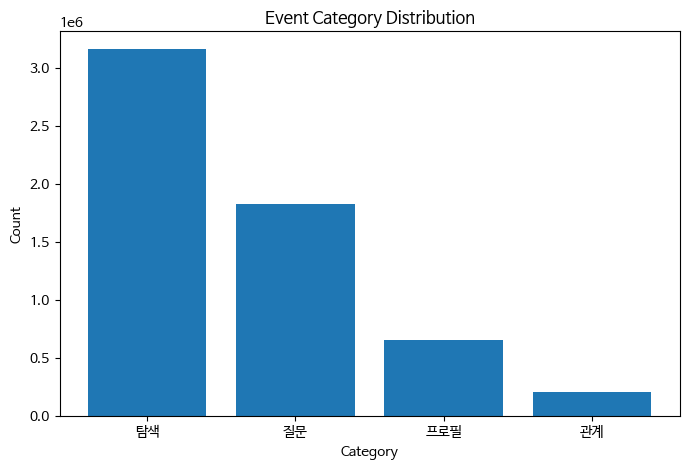

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    category_counts['event_category'],
    category_counts['count']
)

plt.title('Event Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')

plt.show()

## 3-1.서비스 구조 카테고리 분석

## 분석 목적

유저가 서비스 내에서
어떤 행동을 주로 수행하는지 파악하고,

핵심 기능까지 실제 참여가 이어지는 구조인지 확인하기 위함이다.

---

# 카테고리별 이벤트 분포

| 카테고리 | count |
|---|---|
| 탐색 | 3,162,343 |
| 질문 | 1,827,843 |
| 프로필 | 650,607 |
| 관계 | 200,371 |

---

# 시각화 결과 해석

## 1. 탐색 행동 비중이 가장 높음

탐색 카테고리 이벤트가
전체 카테고리 중 가장 높은 비중을 차지하였다.

대표 이벤트:

- view_lab_tap
- view_timeline_tap

---

## 해석

유저는 서비스 내부를 탐색하거나
콘텐츠를 둘러보는 행동은 활발하게 수행하고 있었다.

즉,

```text
서비스 진입 자체에는 큰 문제가 없을 가능성
```

이 존재한다.

---

# 2. 질문 행동은 탐색 대비 크게 감소

질문 카테고리 이벤트는
탐색 이벤트 대비 크게 낮은 수준으로 나타났다.

대표 이벤트:

- click_question_open
- click_question_start
- complete_question

---

## 해석

유저는 질문 콘텐츠를 열람하거나 접근은 하지만,

실제 질문 수행 단계까지
깊게 이어지지 않는 구조를 보였다.

---

## 핵심 인사이트

```text
유저는 서비스를 탐색하지만,
핵심 기능인 질문 수행 단계까지는
충분히 참여하지 않는다.
```

---

# 3. 관계 기능 비중이 매우 낮음

관계 카테고리 이벤트는
전체 이벤트 중 가장 낮은 수준으로 나타났다.

대표 이벤트:

- click_friend_invite
- click_invite_friend
- click_community_chat

---

## 해석

서비스는 질문 소비 중심 구조에 비해,

친구 관계 형성 및
지속 사용을 유도하는 구조는 약한 가능성이 존재한다.

---

## 핵심 인사이트

```text
서비스가 반복 방문 및 관계 유지보다는,
단기 소비 구조에 가까운 형태를 보였다.
```

---

# 4. 프로필 행동은 중간 수준

프로필 관련 행동은
탐색과 질문 사이 수준으로 나타났다.

이는 일부 유저는
프로필 기반 행동을 수행하지만,

서비스 핵심 구조로 강하게 연결되지는 않았을 가능성을 시사한다.

---

# 최종 결론

```text
유저는 서비스 내부 탐색 행동은 활발하게 수행하지만,

핵심 기능인 질문 수행 단계에서는
깊은 참여로 이어지지 않는 구조를 보였다.

또한 관계 기능 사용 비중이 낮아,
서비스가 지속 사용 구조보다는
단기 소비 구조에 가까운 형태를 가진 것으로 판단된다.
```

# 4.퍼널분석


In [ ]:
# 퍼널 이벤트 정의

funnel_events = [
    'launch_app',
    'click_question_open',
    'click_question_start',
    'complete_question'
]

In [ ]:
# 퍼널 이벤트 집계

funnel_counts = (
    event[event['event_key'].isin(funnel_events)]
    ['event_key']
    .value_counts()
    .reindex(funnel_events)
    .reset_index()
)

funnel_counts.columns = ['event', 'count']

funnel_counts

,event,count
0,launch_app,942729
1,click_question_open,805424
2,click_question_start,217617
3,complete_question,152262


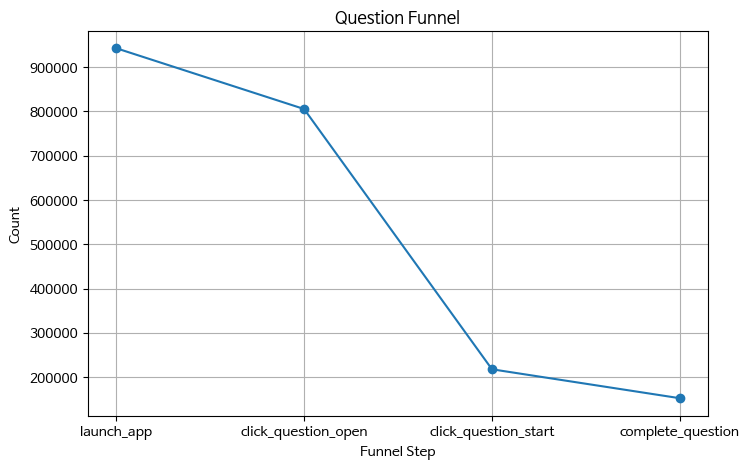

In [ ]:
# 퍼널 시각화

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    funnel_counts['event'],
    funnel_counts['count'],
    marker='o'
)

plt.title('Question Funnel')
plt.xlabel('Funnel Step')
plt.ylabel('Count')

plt.grid()

plt.show()

In [ ]:
# 전환율 계산

launch = funnel_counts.loc[
    funnel_counts['event'] == 'launch_app',
    'count'
].values[0]

open_q = funnel_counts.loc[
    funnel_counts['event'] == 'click_question_open',
    'count'
].values[0]

start_q = funnel_counts.loc[
    funnel_counts['event'] == 'click_question_start',
    'count'
].values[0]

complete_q = funnel_counts.loc[
    funnel_counts['event'] == 'complete_question',
    'count'
].values[0]

print("질문 진입률:", open_q / launch)
print("질문 시작률:", start_q / launch)
print("질문 완료율:", complete_q / launch)

질문 진입률: 0.8543536901909244
질문 시작률: 0.23083728197605038
질문 완료율: 0.16151195094242354


In [ ]:
# skip 비교

skip_count = event[
    event['event_key'] == 'skip_question'
].shape[0]

print("skip 수:", skip_count)
print("complete 수:", complete_q)
print("skip / complete:", skip_count / complete_q)

skip 수: 449595
complete 수: 152262
skip / complete: 2.952772195294952


## 4-2.퍼널 분석 해석

# 질문 퍼널 분석 (Question Funnel Analysis)

## 분석 목적

유저가 질문 수행 과정의
어느 단계에서 이탈하는지 확인하기 위함이다.

---

# 질문 퍼널 구조

```text
launch_app
→ click_question_open
→ click_question_start
→ complete_question
```

---

# 퍼널 단계별 이벤트 수

| 단계 | count |
|---|---|
| launch_app | 942,729 |
| click_question_open | 805,424 |
| click_question_start | 217,617 |
| complete_question | 152,262 |

---

# 퍼널 전환율

| 지표 | 비율 |
|---|---|
| 질문 진입률 | 85.4% |
| 질문 시작률 | 23.1% |
| 질문 완료율 | 16.2% |

---

# skip 비교 분석

| 지표 | count |
|---|---|
| skip_question | 449,595 |
| complete_question | 152,262 |

---

## skip / complete 비율

```text
skip ≈ complete의 2.95배
```

---

# 분석 결과 해석

## 1. 질문 열람까지는 비교적 높은 비율 유지

launch_app 대비
click_question_open 비율은 약 85.4%로 나타났다.

---

## 해석

유저는 서비스에 진입한 이후,

질문 콘텐츠 자체를 열람하거나
탐색하는 행동은 활발하게 수행하고 있었다.

즉,

```text
서비스 진입 및 콘텐츠 접근 자체에는
큰 문제가 없을 가능성
```

이 존재한다.

---

# 2. 질문 시작 단계에서 급격한 감소 발생

click_question_open 이후

click_question_start 단계에서
이벤트 수가 크게 감소하였다.

| 이벤트 | count |
|---|---|
| click_question_open | 805,424 |
| click_question_start | 217,617 |

---

## 해석

유저는 질문을 열람하지만,

실제 질문 수행 단계까지
깊게 참여하지 않는 구조를 보였다.

---

## 핵심 인사이트

```text
질문 열람과 실제 질문 참여 사이에
큰 이탈 구간이 존재한다.
```

---

# 3. 질문 완료율은 매우 낮은 수준

complete_question 비율은
launch_app 대비 약 16.2% 수준으로 나타났다.

---

## 해석

대부분 유저는 질문 수행 과정에서
완료 단계까지 이어지지 못하고 있었다.

---

# 4. skip 행동이 매우 높게 나타남

skip_question 이벤트는
complete_question 대비 약 2.95배 높게 나타났다.

---

## 해석

유저는 질문 수행 과정에서
질문 완료보다 skip 행동을 훨씬 많이 수행하였다.

---

## 핵심 인사이트

```text
핵심 이탈 구간은 질문 수행 단계로 판단된다.
```

즉,

유저는 질문 콘텐츠 자체를 싫어하기보다,

질문을 수행하는 과정에서
높은 비율로 이탈하고 있을 가능성이 존재한다.

---

# 최종 결론

```text
유저는 질문 콘텐츠를 열람하고 탐색하는 행동은 활발하게 수행하지만,

질문 수행 단계에서는
대규모 이탈이 발생하고 있었다.

특히 질문 시작 이후
skip 행동이 완료 행동 대비 약 3배 높게 나타나,

핵심 문제는 질문 수행 UX 및 참여 구조에 있을 가능성이 높다.
```

# 5.skip 시간 분석

In [ ]:
# 질문 관련 이벤트만 추출

question_event = event[
    event['event_key'].isin([
        'click_question_start',
        'skip_question',
        'complete_question'
    ])
].copy()

In [ ]:
# 시간순 정렬

question_event = question_event.sort_values([
    'session_id',
    'event_datetime'
])

In [ ]:
# 이전 이벤트 생성

question_event['prev_event'] = (
    question_event
    .groupby('session_id')['event_key']
    .shift(1)
)

question_event['prev_time'] = (
    question_event
    .groupby('session_id')['event_datetime']
    .shift(1)
)

In [ ]:
#시간 차 계산

question_event['time_diff_sec'] = (
    question_event['event_datetime']
    - question_event['prev_time']
).dt.total_seconds()

In [ ]:
# start → skip만 추출

skip_analysis = question_event[
    (question_event['event_key'] == 'skip_question') &
    (question_event['prev_event'] == 'click_question_start')
]

In [ ]:
skip_analysis['time_diff_sec'].describe()

,time_diff_sec
count,111954.000000
mean,61.186657
std,1083.913980
min,2.000000
25%,5.000000
50%,14.000000
75%,35.000000
max,222074.000000


In [ ]:
filtered_skip = skip_analysis[
    skip_analysis['time_diff_sec'] <= 300
]

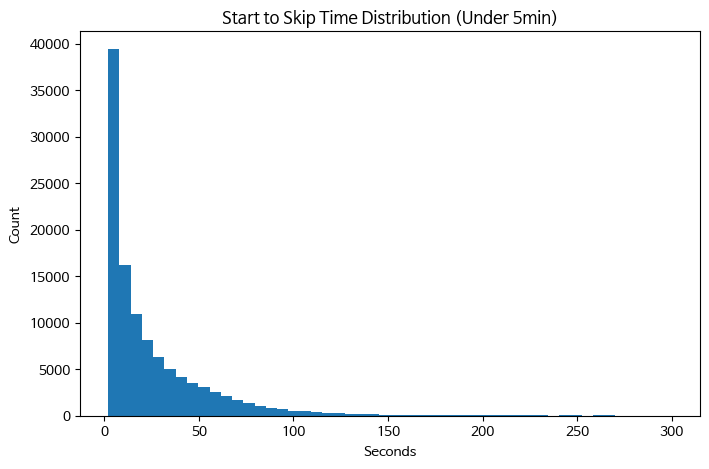

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    filtered_skip['time_diff_sec'],
    bins=50
)

plt.title('Start to Skip Time Distribution (Under 5min)')
plt.xlabel('Seconds')
plt.ylabel('Count')

plt.show()

## 5-2.질문 시작 후 skip 시간 분석

## 분석 목적

질문 수행 과정에서 발생하는 이탈이

콘텐츠 문제인지,
혹은 UX 구조 문제인지 확인하기 위함이다.

---

# 분석 방법

질문 시작 이벤트(click_question_start) 이후

바로 이어지는 skip_question 이벤트까지의
시간 차이를 계산하였다.

---

# 분석 결과

| 지표 | 값 |
|---|---|
| count | 111,954 |
| 평균 | 61.2초 |
| 중앙값 | 14초 |
| 25% | 5초 |
| 75% | 35초 |

---

# 시각화 결과 해석

히스토그램 분석 결과,

대부분의 skip 이벤트가
매우 짧은 시간 구간에 집중되어 나타났다.

특히:

- 25% 유저는 5초 이내 skip
- 중앙값은 14초

수준으로 확인되었다.

---

# 핵심 인사이트

```text
유저는 질문을 충분히 고민한 뒤 이탈하기보다,

질문 시작 직후 매우 빠르게 이탈하는 패턴을 보였다.
```

---

# 해석

만약 콘텐츠 자체가 핵심 문제였다면,

유저는 질문을 어느 정도 읽고 고민한 이후
이탈하는 패턴이 나타날 가능성이 높다.

하지만 실제 데이터에서는

질문 시작 직후 매우 짧은 시간 안에
skip 행동이 집중되는 구조가 확인되었다.

---

# 분석 의미

이는 단순 콘텐츠 품질 문제보다는,

- 질문 UX 구조
- 질문 방식
- 참여 피로도
- 인터랙션 구조

등의 문제가 존재할 가능성을 시사한다.

---

# 추가 해석

평균값(mean)은 약 61초였지만,

최대값(max)이 매우 크게 존재하여
이상치 영향이 포함된 것으로 판단된다.

따라서 실제 유저 행동을 대표하는 값은

평균보다 중앙값(14초)이
더 적절한 지표로 판단된다.

---

# 최종 결론

```text
질문 수행 과정의 이탈은
긴 고민 끝에 발생하는 이탈이라기보다,

질문 시작 직후 빠르게 발생하는 구조에 가까웠다.

이는 질문 콘텐츠 자체보다,
질문 수행 UX 및 참여 구조의 문제 가능성을 강화하는 결과로 해석된다.
```

# 6.세션 깊이 분석

In [ ]:
# 세션당 이벤트 수 계산

session_depth = (
    event.groupby('session_id')
    .size()
    .reset_index(name='event_count')
)

session_depth.head()

,session_id,event_count
0,00025EE1-BA46-4853-8FDD-B991FABA328F,50
1,0004F43C-3A7A-4DE4-A02B-55AFDF07E9AD,42
2,00057831-A672-4163-9C02-AB920A371F2C,44
3,000638C3-2BC2-4068-A482-861B526B2651,31
4,00077002-3194-4c04-8ce0-2945041865f2,3


In [ ]:
# 기초 통계 확인

session_depth['event_count'].describe()

,event_count
count,228923.000000
mean,48.721387
std,121.258745
min,1.000000
25%,12.000000
50%,25.000000
75%,49.000000
max,8157.000000


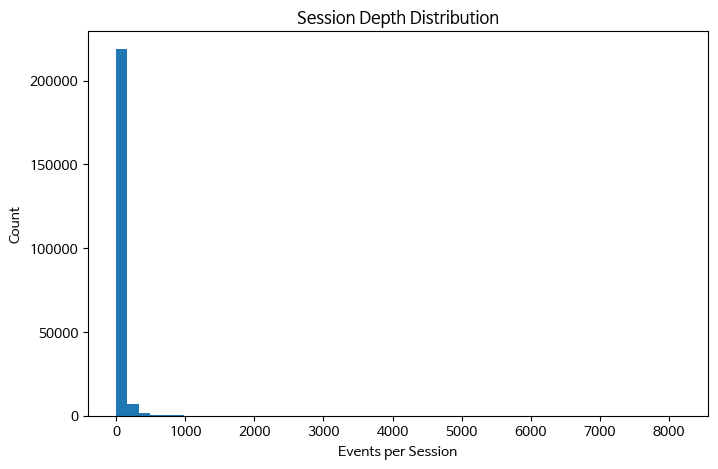

In [ ]:


plt.figure(figsize=(8,5))

plt.hist(
    session_depth['event_count'],
    bins=50
)

plt.title('Session Depth Distribution')
plt.xlabel('Events per Session')
plt.ylabel('Count')

plt.show()

In [ ]:
filtered_session = session_depth[
    session_depth['event_count'] <= 100
]

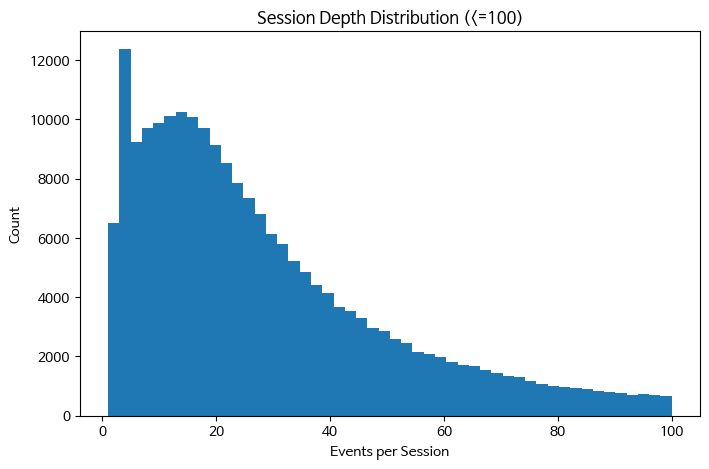

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    filtered_session['event_count'],
    bins=50
)

plt.title('Session Depth Distribution (<=100)')
plt.xlabel('Events per Session')
plt.ylabel('Count')

plt.show()

In [ ]:
# 세션 길이 계산

session_time = (
    event.groupby('session_id')['event_datetime']
    .agg(['min', 'max'])
)

session_time['duration_sec'] = (
    session_time['max']
    - session_time['min']
).dt.total_seconds()

session_time.head()

,min,max,duration_sec
session_id,,,
00025EE1-BA46-4853-8FDD-B991FABA328F,2023-07-22 23:30:09,2023-07-30 19:40:37,677428.0
0004F43C-3A7A-4DE4-A02B-55AFDF07E9AD,2023-07-26 18:53:38,2023-08-07 20:31:49,1042691.0
00057831-A672-4163-9C02-AB920A371F2C,2023-07-26 09:47:49,2023-08-07 22:53:42,1083953.0
000638C3-2BC2-4068-A482-861B526B2651,2023-07-23 01:02:40,2023-07-24 01:42:10,88770.0
00077002-3194-4c04-8ce0-2945041865f2,2023-07-21 23:24:28,2023-07-21 23:24:32,4.0


In [ ]:
# 세션 길이 통계

session_time['duration_sec'].describe()

,duration_sec
count,2.289230e+05
mean,4.989072e+05
std,6.309077e+05
min,0.000000e+00
25%,7.900000e+01
50%,9.867800e+04
75%,9.634835e+05
max,2.073309e+06


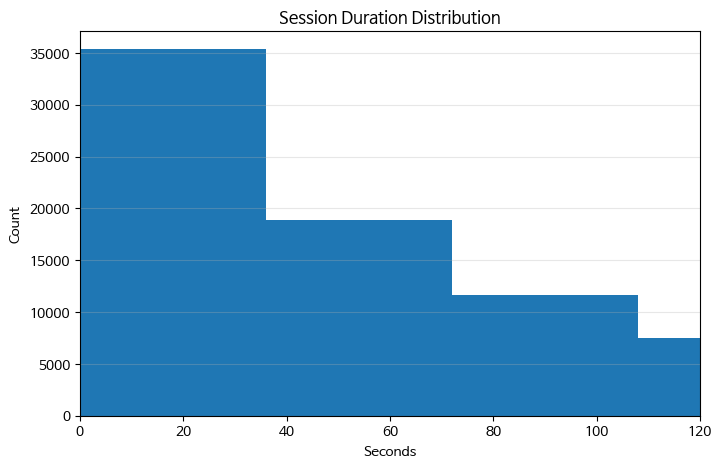

In [ ]:
filtered_duration = session_time[
    session_time['duration_sec'] <= 1800
]

plt.figure(figsize=(8,5))

plt.hist(
    filtered_duration['duration_sec'],
    bins=50
)
plt.xlim(0, 120)
plt.grid(axis='y', alpha=0.3)
plt.title('Session Duration Distribution')
plt.xlabel('Seconds')
plt.ylabel('Count')

plt.show()

## 6-1.세션 깊이 및 세션 지속 시간 분석

## 분석 목적

유저가 서비스를 얼마나 깊게 사용하는지 확인하고,

서비스가 단순 짧은 소비 구조인지,
혹은 특정 단계에서 이탈이 발생하는 구조인지 분석하기 위함이다.

---

# 1. 세션 깊이 분석

## 분석 방법

세션(session_id) 기준으로

세션당 발생한 이벤트 수(event_count)를 계산하였다.

---

# 세션당 이벤트 수 통계

| 지표 | 값 |
|---|---|
| 전체 세션 수 | 228,923 |
| 평균 | 48.7 |
| 중앙값 | 25 |
| 25% | 12 |
| 75% | 49 |
| 최대값 | 8,157 |

---

# 시각화 결과 해석

히스토그램 분석 결과,

세션당 이벤트 수는
낮은 구간에 집중되면서도,

중간 수준 이상의 이벤트를 수행하는 세션도
상당수 존재하는 구조를 보였다.

---

# 핵심 인사이트

```text
유저는 단순히 앱을 짧게 사용하고 바로 종료하는 구조만 존재하는 것이 아니라,

일정 수준 이상의 탐색 및 행동은 수행하고 있었다.
```

---

# 해석

중앙값 기준 세션당 약 25개의 이벤트가 발생하였으며,

일부 세션은
40~50개 이상의 이벤트를 수행하는 패턴도 확인되었다.

즉,

```text
서비스 자체 사용량은 완전히 낮은 수준이 아니었다.
```

---

# 분석 의미

이는 단순히

```text
“앱 자체를 사용하지 않는다”
```

의 문제가 아니라,

특정 기능 단계,
특히 질문 수행 단계에서의 이탈 가능성을 더욱 강화하는 결과로 해석된다.

---

# 추가 해석

최대값(max)이 매우 크게 나타난 것은

일부 헤비 유저 혹은
장시간 사용 세션이 존재함을 의미한다.

다만 전체 분포는
중간 이하 구간에 많이 집중되어 있어,

서비스 사용 깊이의 편차가 큰 구조로 판단된다.

---

# 2. 세션 지속 시간 분석

## 분석 방법

세션별 최초 이벤트(min)와
마지막 이벤트(max) 간의 시간 차이를 계산하여

세션 지속 시간(duration_sec)을 생성하였다.

---

# 세션 지속 시간 통계

| 지표 | 값 |
|---|---|
| 평균 | 498,907초 |
| 중앙값 | 98,678초 |
| 25% | 79초 |
| 75% | 963,483초 |
| 최대값 | 2,073,309초 |

---

# 시각화 결과 해석

히스토그램 분석 결과,

짧은 시간 안에 종료되는 세션이
가장 높은 비중을 차지하는 구조가 확인되었다.

특히 대부분 세션은
초기 짧은 구간에 집중되어 나타났다.

---

# 이상치 문제 확인

일부 세션은
수일 이상 지속되는 형태로 기록되어 있었다.

예시:

| session_id | duration_sec |
|---|---|
| 00057831... | 1,083,953초 |
| 0004F43C... | 1,042,691초 |

---

## 해석

이는 실제 단일 사용 세션이라기보다,

- session_id 재사용
- 앱 백그라운드 유지
- 로그 누적 기록

등의 영향일 가능성이 존재한다.

따라서 평균(mean)은
이상치 영향을 크게 받은 것으로 판단된다.

---

# 핵심 인사이트

```text
실제 유저 행동을 대표하는 값은
평균보다 짧은 구간 분포 및 중앙값 해석이 더 중요하다.
```

---

# 종합 해석

세션 깊이 분석에서는

유저가 일정 수준 이상의 탐색 및 행동을 수행하는 패턴이 확인되었다.

반면,

질문 퍼널 및 skip 분석에서는

질문 수행 단계에서
높은 비율의 빠른 이탈이 발생하였다.

---

# 최종 결론

```text
유저는 서비스 자체를 매우 짧게만 사용하는 구조라기보다,

서비스 내부 탐색과 행동은 일정 수준 수행하고 있었다.

하지만 질문 수행 단계에서는
빠른 이탈이 반복적으로 발생하고 있었으며,

핵심 문제는
서비스 전체 사용량 부족보다,

질문 수행 UX 및 참여 구조에 있을 가능성이 높다.
```

# 7.질문 행동 세션 vs 일반 세션 비교

In [ ]:
# 질문 행동 포함 세션 추출

question_sessions = event[
    event['event_key'].isin([
        'click_question_open',
        'click_question_start',
        'complete_question',
        'skip_question'
    ])
]['session_id'].unique()

In [ ]:
# 질문 세션 여부 컬럼 생성

session_depth['question_session'] = (
    session_depth['session_id']
    .isin(question_sessions)
)

In [ ]:
# 그룹별 통계 비교

session_depth.groupby(
    'question_session'
)['event_count'].describe()

,count,mean,std,min,25%,50%,75%,max
question_session,,,,,,,,
False,94329.0,19.100584,23.329152,1.0,6.0,14.0,24.0,1669.0
True,134594.0,69.480861,153.562358,2.0,21.0,37.0,69.0,8157.0


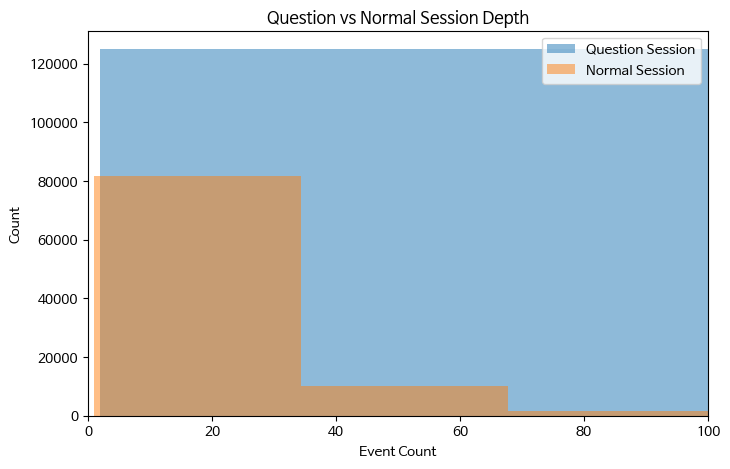

In [ ]:
import matplotlib.pyplot as plt

question_group = session_depth[
    session_depth['question_session'] == True
]['event_count']

normal_group = session_depth[
    session_depth['question_session'] == False
]['event_count']

plt.figure(figsize=(8,5))

plt.hist(
    question_group,
    bins=50,
    alpha=0.5,
    label='Question Session'
)

plt.hist(
    normal_group,
    bins=50,
    alpha=0.5,
    label='Normal Session'
)

plt.xlim(0,100)

plt.legend()

plt.title('Question vs Normal Session Depth')
plt.xlabel('Event Count')
plt.ylabel('Count')

plt.show()

## 7-1.질문 세션 vs 일반 세션 비교 분석

## 분석 목적

질문 행동이 포함된 세션과
일반 세션의 사용 패턴 차이를 비교하여,

질문 기능 자체가
서비스 사용 깊이에 어떤 영향을 가지는지 확인하기 위함이다.

---

# 분석 방법

질문 관련 이벤트가 포함된 세션을
question_session으로 정의하였다.

질문 관련 이벤트:

- click_question_open
- click_question_start
- complete_question
- skip_question

이후,

세션당 이벤트 수(event_count)를 기준으로

- 질문 세션
- 일반 세션

을 비교하였다.

---

# 세션별 이벤트 수 통계

| 구분 | 일반 세션 | 질문 세션 |
|---|---|---|
| 세션 수 | 94,329 | 134,594 |
| 평균 이벤트 수 | 19.1 | 69.5 |
| 중앙값 | 14 | 37 |
| 25% | 6 | 21 |
| 75% | 24 | 69 |

---

# 시각화 결과 해석

질문 세션(question_session)은

일반 세션 대비
훨씬 높은 이벤트 수를 가지는 구조를 보였다.

즉,

질문 행동이 포함된 세션은
서비스 사용량 자체가 더 높은 특성을 보였다.

---

# 핵심 인사이트

```text
질문 행동을 수행하는 유저는
서비스 활동성이 높은 유저일 가능성이 존재한다.
```

---

# 이전 분석과의 연결

앞선 분석에서는

- 질문 수행 단계에서 높은 이탈 발생
- skip 행동이 빠르게 발생
- 질문 완료율이 낮음

등의 결과가 확인되었다.

하지만 이번 분석에서는

질문 세션 자체는
일반 세션보다 더 깊고 활발한 사용 패턴을 보였다.

---

# 종합 해석

이는 단순히

```text
“질문 기능을 사용하는 유저가 적다”
```

의 문제가 아니라,

```text
질문 기능을 사용하는 유저조차
질문 수행 단계에서 반복적으로 이탈하고 있다
```

는 방향으로 해석할 수 있다.

---

# 분석 의미

서비스 자체 수요와 활동성은 존재하지만,

질문 수행 UX 과정에서
반복적인 마찰(frction) 혹은 피로도가 발생하고 있을 가능성이 존재한다.

즉,

핵심 문제는

```text
서비스 전체 사용량 부족
```

보다는,

```text
질문 수행 과정 내부의 UX 구조 문제
```

에 가까운 것으로 판단된다.

---

# 최종 결론

```text
질문 행동이 포함된 유저는
서비스 활동성이 높은 편이었지만,

질문 수행 단계에서는
빠른 skip과 높은 이탈이 반복적으로 발생하고 있었다.

이는 서비스 자체 문제보다,

질문 UX 및 참여 구조 문제 가능성을 더욱 강화하는 결과로 해석된다.
```

# 8.첫 질문 분석

In [ ]:
# 질문 이벤트만 추출

question_only = event[
    event['event_key'].isin([
        'skip_question',
        'complete_question'
    ])
].copy()

In [ ]:
# 시간순 정렬

question_only = question_only.sort_values([
    'user_id',
    'event_datetime'
])

In [ ]:
# 유저별 첫 질문 결과 추출

first_question_result = (
    question_only
    .groupby('user_id')
    .first()
    .reset_index()
)

In [ ]:
# 첫 질문 결과 분포 확인

first_result_counts = (
    first_question_result['event_key']
    .value_counts()
    .reset_index()
)

first_result_counts.columns = [
    'first_result',
    'count'
]

first_result_counts

,first_result,count
0,skip_question,34556
1,complete_question,18552


In [ ]:
# 비율 확인

first_result_counts['ratio'] = (
    first_result_counts['count']
    / first_result_counts['count'].sum()
)

first_result_counts

,first_result,count,ratio
0,skip_question,34556,0.650674
1,complete_question,18552,0.349326


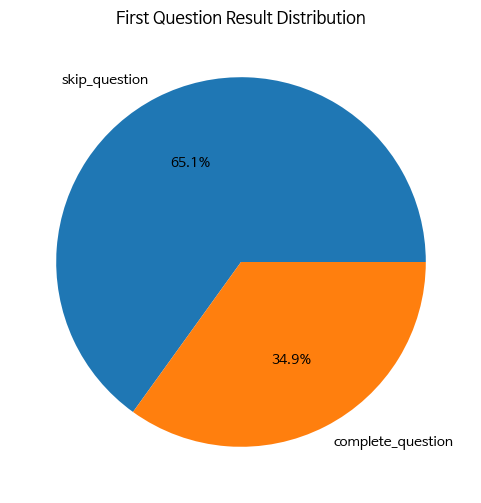

In [ ]:
# 시각화

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.pie(
    first_result_counts['count'],
    labels=first_result_counts['first_result'],
    autopct='%1.1f%%'
)

plt.title('First Question Result Distribution')

plt.show()

## 8-1.첫 질문 결과 분석 (First Question Analysis)

## 분석 목적

유저의 첫 질문 경험이

서비스 이탈 및 참여 행동에
영향을 미치는지 확인하기 위함이다.

---

# 분석 방법

유저별로 최초 발생한 질문 결과를 추출하여,

첫 질문이

- skip_question
- complete_question

중 어떤 결과로 이어졌는지 분석하였다.

---

# 첫 질문 결과 분포

| 첫 질문 결과 | count | ratio |
|---|---|---|
| skip_question | 34,548 | 65.1% |
| complete_question | 18,560 | 34.9% |

---

# 시각화 결과 해석

유저의 첫 질문 결과는

skip_question 비율이
complete_question 대비 훨씬 높게 나타났다.

특히:

```text
첫 질문부터 약 65%가 skip으로 종료
```

되는 구조가 확인되었다.

---

# 핵심 인사이트

```text
유저는 첫 질문 경험 단계부터
높은 비율로 이탈하고 있었다.
```

---

# 해석

만약 문제의 원인이 단순 반복 피로도였다면,

초기 질문에서는 상대적으로 높은 완료율이 나타나고,

반복 사용 이후 skip 비율이 증가하는 구조가 예상된다.

하지만 실제 데이터에서는

첫 질문 단계부터
높은 skip 비율이 발생하였다.

---

# 분석 의미

이는 단순 콘텐츠 반복 문제 이전에,

- 첫 질문 UX
- 질문 진입 구조
- 질문 인터랙션 방식
- 초기 참여 허들

등의 문제가 존재할 가능성을 시사한다.

즉,

```text
문제는 반복 사용 이후가 아니라,
첫 경험 단계부터 발생하고 있을 가능성
```

이 존재한다.

---

# 이전 분석과의 연결

앞선 분석에서는

- 질문 수행 단계에서 높은 이탈 발생
- start → skip 시간이 매우 짧음
- 질문 세션 자체는 활동성이 높음

등의 결과가 확인되었다.

이번 분석에서는

첫 질문 단계 자체에서도
높은 skip 비율이 발생하는 구조가 추가로 확인되었다.

---

# 종합 해석

이는 단순히

```text
“질문 콘텐츠가 반복되어 피로하다”
```

의 문제가 아니라,

```text
질문 경험 자체가
초기부터 사용자에게 충분한 몰입을 제공하지 못하고 있을 가능성
```

을 강화하는 결과로 해석된다.

---

# 최종 결론

```text
유저는 질문 기능을 사용하는 단계까지는 도달하지만,

첫 질문 경험 단계부터
높은 비율로 skip 행동을 수행하고 있었다.

이는 질문 콘텐츠 자체 이전에,

질문 수행 UX 및 초기 참여 구조 문제 가능성을 강화하는 결과로 판단된다.
```

# 9.행동 흐름 분석

## 9-1. skip 직전 이벤트

In [ ]:
# 시간순 정렬

event = event.sort_values([
    'session_id',
    'event_datetime'
])

In [ ]:
# 이전 이벤트 생성

event['prev_event'] = (
    event.groupby('session_id')['event_key']
    .shift(1)
)

In [ ]:
# skip 직전 이벤트 추출

skip_prev = event[
    event['event_key'] == 'skip_question'
]

In [ ]:
# 직전 이벤트 빈도 확인

skip_prev_counts = (
    skip_prev['prev_event']
    .value_counts()
    .reset_index()
)

skip_prev_counts.columns = [
    'prev_event',
    'count'
]

skip_prev_counts.head(20)

,prev_event,count
0,skip_question,322756
1,click_question_start,110542
2,complete_question,14546
3,$session_start,664
4,click_bottom_navigation_questions,509
5,view_questions_tap,314
6,view_timeline_tap,112
7,view_lab_tap,105
8,$session_end,24
9,click_question_open,7


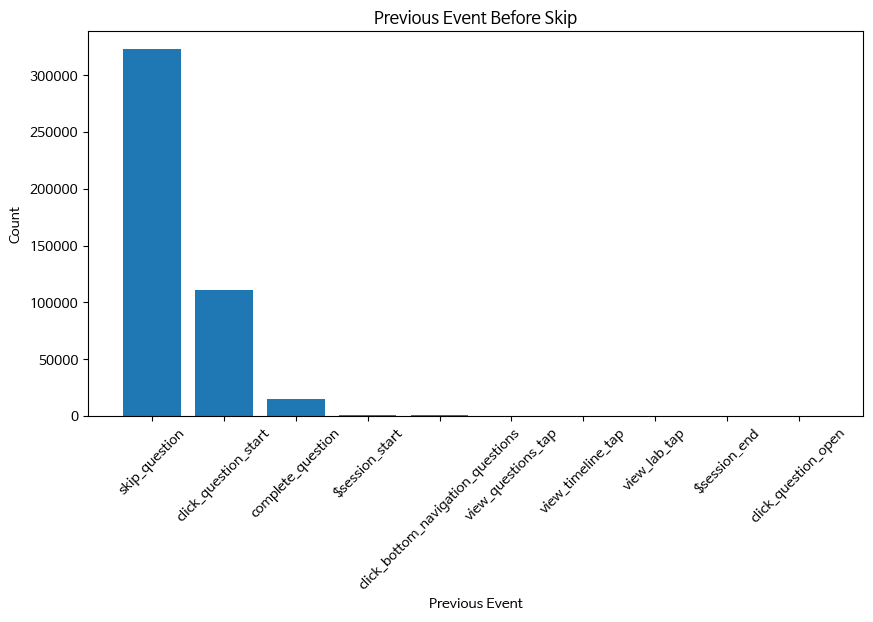

In [ ]:
# 시각화

import matplotlib.pyplot as plt

top_skip_prev = skip_prev_counts.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_skip_prev['prev_event'],
    top_skip_prev['count']
)

plt.xticks(rotation=45)

plt.title('Previous Event Before Skip')
plt.xlabel('Previous Event')
plt.ylabel('Count')

plt.show()

### 9-1.skip 직전 행동 흐름 분석 (Behavior Flow Before Skip)

## 분석 목적

유저가 질문을 skip하기 직전에
어떤 행동 흐름을 보이는지 확인하여,

이탈 원인 및 질문 UX 구조 문제를 파악하기 위함이다.

---

# 분석 방법

세션(session_id) 기준으로

각 이벤트의 직전 이벤트(prev_event)를 생성한 뒤,

skip_question 발생 직전의 행동을 분석하였다.

---

# skip 직전 이벤트 TOP 분석

| prev_event | count |
|---|---|
| skip_question | 322,756 |
| click_question_start | 110,542 |
| complete_question | 14,546 |
| $session_start | 664 |
| click_bottom_navigation_questions | 509 |

---

# 시각화 결과 해석

skip_question 직전 이벤트로

skip_question 자체가
가장 높은 비율로 나타났다.

즉,

```text
유저는 한 번 skip한 이후에도
반복적으로 skip 행동을 수행하는 구조
```

가 확인되었다.

---

# 핵심 인사이트 1

```text
skip은 단발성 행동이 아니라,
반복적으로 발생하는 행동 패턴일 가능성이 존재한다.
```

---

# 해석

이는 단순히 특정 질문 하나의 문제라기보다,

- 질문 경험 구조
- 질문 반복 방식
- 콘텐츠 피로도
- 질문 인터랙션 UX

등의 문제가 누적적으로 작용하고 있을 가능성을 시사한다.

---

# 핵심 인사이트 2

두 번째로 높은 직전 이벤트는

click_question_start였다.

| prev_event | count |
|---|---|
| click_question_start | 110,542 |

---

# 해석

이는 많은 유저가

```text
질문 시작 직후
바로 skip으로 이어지는 패턴
```

을 보이고 있음을 의미한다.

---

# 종합 해석

현재 데이터에서는

두 가지 이탈 구조가 동시에 존재하는 것으로 판단된다.

---

# 1. 즉시 이탈 구조

```text
click_question_start
→ skip_question
```

---

## 의미

- 질문 진입 UX 문제
- 질문 인터랙션 진입 허들
- 첫 반응 단계의 몰입 부족

가능성 존재

---

# 2. 반복 skip 구조

```text
skip_question
→ skip_question
```

---

## 의미

- 질문 피로도
- 반복 소비 구조
- 콘텐츠 disengagement

가능성 존재

---

# 분석 의미

이는 단순히

```text
“질문 하나의 품질 문제”
```

가 아니라,

```text
질문 경험 구조 전체에서
반복적인 disengagement가 발생하고 있을 가능성
```

을 시사한다.

---

# 이전 분석과의 연결

앞선 분석에서는

- 질문 단계에서 높은 이탈 발생
- 빠른 skip 발생
- 첫 질문 단계부터 높은 skip 비율

등이 확인되었다.

이번 분석에서는

skip 이후에도
다시 skip이 반복되는 구조가 추가로 확인되었다.

---

# 최종 결론

```text
유저는 질문 기능에 진입하고 있었지만,

질문 수행 과정에서는

- 시작 직후 빠른 이탈
- 반복적인 skip 행동

이 동시에 발생하고 있었다.

이는 질문 UX 구조 및 반복 소비 경험 전반에
문제가 존재할 가능성을 강화하는 결과로 해석된다.
```

## 9-2. complete_question 이후 event

In [ ]:
# complete 이벤트 추출

complete_df = event[
    event['event_key'] == 'complete_question'
].copy()

In [ ]:
# 다음 이벤트 생성

event['next_event'] = (
    event.groupby('session_id')['event_key']
    .shift(-1)
)

In [ ]:
# complete 이후 이벤트 확인

complete_next = event[
    event['event_key'] == 'complete_question'
]

In [ ]:
# 다음 이벤트 빈도 분석

complete_next_counts = (
    complete_next['next_event']
    .value_counts()
    .reset_index()
)

complete_next_counts.columns = [
    'next_event',
    'count'
]

complete_next_counts.head(20)

,next_event,count
0,$session_end,27400
1,click_question_open,19982
2,view_timeline_tap,17780
3,skip_question,14546
4,click_attendance,8959
5,click_bottom_navigation_timeline,7939
6,click_appbar_alarm_center,7851
7,launch_app,7492
8,view_lab_tap,7382
9,click_bottom_navigation_questions,5735


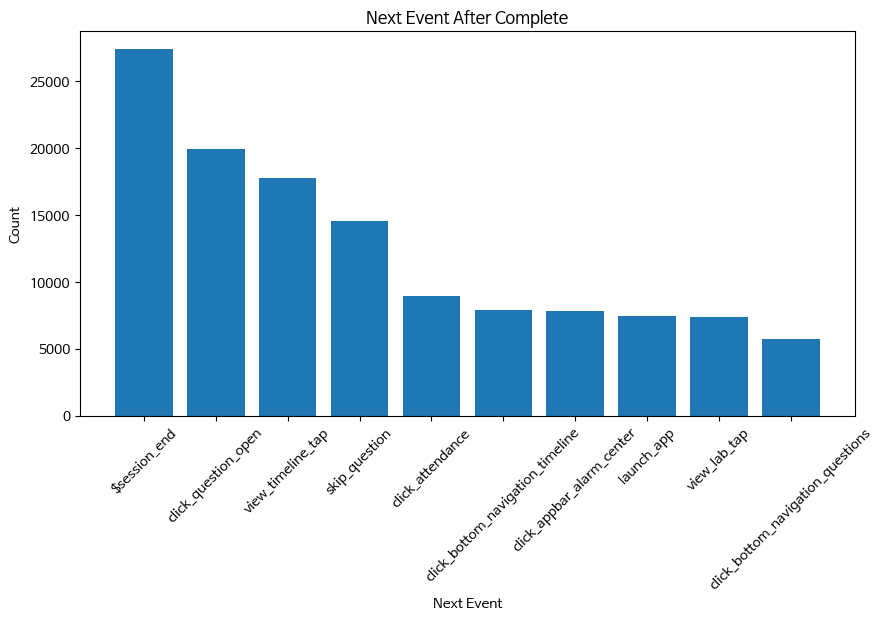

In [ ]:
# 시각화

top_complete_next = complete_next_counts.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_complete_next['next_event'],
    top_complete_next['count']
)

plt.xticks(rotation=45)

plt.title('Next Event After Complete')
plt.xlabel('Next Event')
plt.ylabel('Count')

plt.show()

### complete 이후 행동 흐름 분석 (Behavior Flow After Complete)

## 분석 목적

질문 완료 이후 유저가
어떤 행동 흐름을 보이는지 확인하여,

질문 기능이
서비스 engagement로 이어지는지 분석하기 위함이다.

---

# 분석 방법

세션 기준으로
complete_question 이후 발생한 next_event를 분석하였다.

---

# complete 이후 이벤트 TOP 분석

| next_event | count |
|---|---|
| $session_end | 27,400 |
| click_question_open | 19,982 |
| view_timeline_tap | 17,780 |
| skip_question | 14,546 |
| click_attendance | 8,959 |

---

# 시각화 결과 해석

complete_question 이후
가장 많이 발생한 이벤트는
$session_end였다.

즉,

```text
질문 완료 이후
세션 종료로 이어지는 비율이 높음
```

이 확인되었다.

---

# 핵심 인사이트 1

```text
질문 완료가
항상 지속 engagement로 이어지지는 않았다.
```

---

# 해석

질문 기능은
일부 유저에게는 소비 완료형 행동으로 작동하고 있을 가능성이 존재한다.

즉,

```text
질문 완료 이후
서비스 사용이 종료되는 패턴
```

이 다수 존재하였다.

---

# 핵심 인사이트 2

두 번째로 높은 이벤트는

click_question_open이었다.

| next_event | count |
|---|---|
| click_question_open | 19,982 |

---

# 해석

이는 일부 유저가
질문 완료 이후에도

```text
다음 질문으로 이어지는 행동
```

을 수행하고 있음을 의미한다.

즉,

질문 기능 자체는
반복 engagement 가능성을 가진 구조임이 확인되었다.

---

# 핵심 인사이트 3

complete 이후에도
skip_question이 높은 비율로 나타났다.

| next_event | count |
|---|---|
| skip_question | 14,546 |

---

# 해석

이는 질문 완료 경험 이후에도

```text
다음 질문 단계에서
다시 disengagement가 발생하는 구조
```

가 존재함을 의미한다.

---

# 종합 해석

현재 데이터에서는

질문 기능이

- 일부 유저에게는 반복 engagement
- 일부 유저에게는 소비 종료
- 일부 유저에게는 반복 skip

으로 연결되는 혼합 구조를 보이고 있었다.

---

# 분석 의미

즉,

```text
질문 기능 자체가 완전히 실패한 구조라기보다,

질문 경험 품질에 따라
이후 행동 흐름이 크게 달라지는 구조
```

일 가능성이 존재한다.

---

# 이전 분석과의 연결

앞선 분석에서는

- 질문 시작 직후 빠른 skip
- 첫 질문 단계의 높은 이탈
- 반복 skip 구조

등이 확인되었다.

이번 분석에서는

질문 완료 이후에도

- 재질문 행동
- 세션 종료
- 반복 skip

이 동시에 나타나는 구조가 추가로 확인되었다.

---

# 최종 결론

```text
질문 기능은 일부 유저에게는
반복 engagement를 유도하고 있었지만,

동시에

- 질문 완료 직후 종료
- 반복 skip 발생

구조 역시 함께 존재하고 있었다.

이는 질문 경험 품질 및 UX 구조에 따라
이후 행동 흐름이 크게 달라질 가능성을 시사한다.
```

In [ ]:
# Tableau용 csv 저장 폴더
import os

save_path = '/content/tableau_csv'
os.makedirs(save_path, exist_ok=True)

In [ ]:
category_counts.to_csv(
    f'{save_path}/event_category_distribution.csv',
    index=False
)

In [ ]:
funnel_counts.to_csv(
    f'{save_path}/question_funnel.csv',
    index=False
)

In [ ]:
filtered_skip.to_csv(
    f'{save_path}/skip_time_distribution.csv',
    index=False
)

In [ ]:
session_depth.to_csv(
    f'{save_path}/session_depth.csv',
    index=False
)

In [ ]:
first_result_counts.to_csv(
    f'{save_path}/first_question_result.csv',
    index=False
)

In [ ]:
skip_prev_counts.to_csv(
    f'{save_path}/previous_event_before_skip.csv',
    index=False
)

In [ ]:
complete_next_counts.to_csv(
    f'{save_path}/next_event_after_complete.csv',
    index=False
)

In [ ]:
os.listdir(save_path)

['previous_event_before_skip.csv',
 'skip_time_distribution.csv',
 'first_question_result.csv',
 'event_category_distribution.csv',
 'session_depth.csv',
 'next_event_after_complete.csv',
 'question_funnel.csv']

In [ ]:
from google.colab import files
import shutil

shutil.make_archive(
    '/content/tableau_csv',
    'zip',
    save_path
)

files.download('/content/tableau_csv.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>